# Base Paper Implementation
## Intelligent Intrusion Detection System 
### AE + LSTM + CNN with SMOTE on CICIoT2023

**Architecture:** SMOTE → Parallel(AE, LSTM) → Merge → CNN → Softmax  
**Dataset:** CICIoT2023 — folders: `train/`, `test/`, `validation/`  


## Step 1 — Install Dependencies

In [1]:
!pip install imbalanced-learn scikit-learn pandas numpy matplotlib seaborn torch -q

## Step 2 — Imports & Seed

In [2]:
import os, random, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [3]:
import os

# Search everywhere in /kaggle/input for any file
print('Everything in /kaggle/input:')
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full = os.path.join(root, f)
        size = os.path.getsize(full)
        print(f'  {full}  ({size/1024/1024:.1f} MB)')

Everything in /kaggle/input:
  /kaggle/input/datasets/asadsha/ciciot23/CICIOT23/validation/validation.csv  (331.8 MB)
  /kaggle/input/datasets/asadsha/ciciot23/CICIOT23/test/test.csv  (331.8 MB)
  /kaggle/input/datasets/asadsha/ciciot23/CICIOT23/train/train.csv  (1548.2 MB)


## Step 3 — Mount Google Drive

In [4]:
import os, glob

TRAIN_DIR = '/kaggle/input/datasets/asadsha/ciciot23/CICIOT23/train'
TEST_DIR  = '/kaggle/input/datasets/asadsha/ciciot23/CICIOT23/test'
VAL_DIR   = '/kaggle/input/datasets/asadsha/ciciot23/CICIOT23/validation'

for name, d in [('train', TRAIN_DIR), ('test', TEST_DIR), ('validation', VAL_DIR)]:
    count = len(glob.glob(os.path.join(d, '*.csv')))
    print(f'{name:>12}  ->  {d}  ({count} CSV files)')

       train  ->  /kaggle/input/datasets/asadsha/ciciot23/CICIOT23/train  (1 CSV files)
        test  ->  /kaggle/input/datasets/asadsha/ciciot23/CICIOT23/test  (1 CSV files)
  validation  ->  /kaggle/input/datasets/asadsha/ciciot23/CICIOT23/validation  (1 CSV files)


## Step 4 — Load CSVs from All Three Folders

We combine **train + test + validation** into one DataFrame, then re-split ourselves 70/30 — exactly as the base paper does — so our split is consistent and reproducible.

In [5]:
import pandas as pd

def load_folder(folder_path):
    files = sorted(glob.glob(os.path.join(folder_path, '*.csv')))
    if not files:
        print(f'  WARNING: No CSV files found in {folder_path}')
        return pd.DataFrame()
    dfs = []
    for f in files:
        tmp = pd.read_csv(f, low_memory=False)
        dfs.append(tmp)
        print(f'    {os.path.basename(f)}: {tmp.shape}')
    return pd.concat(dfs, ignore_index=True)

print('Loading TRAIN folder...')
df_train_raw = load_folder(TRAIN_DIR)
print(f'  => {df_train_raw.shape}')

print('Loading TEST folder...')
df_test_raw  = load_folder(TEST_DIR)
print(f'  => {df_test_raw.shape}')

print('Loading VALIDATION folder...')
df_val_raw   = load_folder(VAL_DIR)
print(f'  => {df_val_raw.shape}')

df_raw = pd.concat([df_train_raw, df_test_raw, df_val_raw], ignore_index=True)
print(f'\nTotal combined shape: {df_raw.shape}')

Loading TRAIN folder...
    train.csv: (5491971, 47)
  => (5491971, 47)
Loading TEST folder...
    test.csv: (1176851, 47)
  => (1176851, 47)
Loading VALIDATION folder...
    validation.csv: (1176851, 47)
  => (1176851, 47)

Total combined shape: (7845673, 47)


## Step 5 — Identify Label Column

In [6]:
label_col = None
for col in ['label', 'Label', 'Attack_type', 'attack_type', 'class', 'Class']:
    if col in df_raw.columns:
        label_col = col
        break

print(f'Label column found: [{label_col}]')
print(f'Unique values ({df_raw[label_col].nunique()}):')
print(df_raw[label_col].value_counts().to_string())

Label column found: [label]
Unique values (34):
label
DDoS-ICMP_Flood            1210546
DDoS-UDP_Flood              910741
DDoS-TCP_Flood              756122
DDoS-PSHACK_Flood           687565
DDoS-SYN_Flood              683505
DDoS-RSTFINFlood            678823
DDoS-SynonymousIP_Flood     603358
DoS-UDP_Flood               557495
DoS-TCP_Flood               448927
DoS-SYN_Flood               339804
BenignTraffic               184766
Mirai-greeth_flood          165977
Mirai-udpplain              149664
Mirai-greip_flood           126967
DDoS-ICMP_Fragmentation      75878
MITM-ArpSpoofing             51897
DDoS-UDP_Fragmentation       48614
DDoS-ACK_Fragmentation       48067
DNS_Spoofing                 30349
Recon-HostDiscovery          22550
Recon-OSScan                 16520
Recon-PortScan               13813
DoS-HTTP_Flood               12125
VulnerabilityScan             6214
DDoS-HTTP_Flood               4786
DDoS-SlowLoris                3999
DictionaryBruteForce          2150
B

## Step 6 — Map 33 Attack Labels → 8 Classes
Same grouping as the base paper (Susilo et al. 2025).

In [7]:
LABEL_MAP = {
    'BenignTraffic':            'Benign',
    # ── DDoS ──────────────────────────────────────
    'DDoS-RSTFINFlood':         'DDoS Attack',
    'DDoS-PSHACK_Flood':        'DDoS Attack',
    'DDoS-SYN_Flood':           'DDoS Attack',
    'DDoS-UDP_Flood':           'DDoS Attack',
    'DDoS-TCP_Flood':           'DDoS Attack',
    'DDoS-ICMP_Flood':          'DDoS Attack',
    'DDoS-HTTP_Flood':          'DDoS Attack',
    'DDoS-SlowLoris':           'DDoS Attack',
    'DDoS-ICMP_Fragmentation':  'DDoS Attack',
    'DDoS-UDP_Fragmentation':   'DDoS Attack',
    'DDoS-ACK_Fragmentation':   'DDoS Attack',
    # ── DoS ───────────────────────────────────────
    'DoS-UDP_Flood':            'DoS Attack',
    'DoS-SYN_Flood':            'DoS Attack',
    'DoS-TCP_Flood':            'DoS Attack',
    'DoS-HTTP_Flood':           'DoS Attack',
    # ── Mirai ─────────────────────────────────────
    'Mirai-greeth_flood':       'Mirai Attack',
    'Mirai-greip_flood':        'Mirai Attack',
    'Mirai-udpplain':           'Mirai Attack',
    # ── Reconnaissance ────────────────────────────
    'Recon-PingSweep':          'Recon Attack',
    'Recon-OSScan':             'Recon Attack',
    'Recon-PortScan':           'Recon Attack',
    'VulnerabilityScan':        'Recon Attack',
    'Recon-HostDiscovery':      'Recon Attack',
    # ── Spoofing ──────────────────────────────────
    'DNS_Spoofing':             'Spoofing',
    'MITM-ArpSpoofing':         'Spoofing',
    # ── Web Attacks ───────────────────────────────
    'XSS':                      'Web Attack',
    'CommandInjection':         'Web Attack',
    'SqlInjection':             'Web Attack',
    'Backdoor_Malware':         'Web Attack',
    'Uploading_Attack':         'Web Attack',
    # ── Brute Force ───────────────────────────────
    'BruteForce-Web':           'Brute Force',
    'BruteForce-XSS':           'Brute Force',
    'DDOS-SlowHTTPTest':        'Brute Force',
}

df_raw['attack_class'] = df_raw[label_col].map(LABEL_MAP)

before = len(df_raw)
unmapped = df_raw[df_raw['attack_class'].isnull()][label_col].value_counts()
if len(unmapped):
    print(f'Unmapped labels (will be dropped):')
    print(unmapped.to_string())
df_raw = df_raw.dropna(subset=['attack_class'])
print(f'Dropped {before - len(df_raw)} unmapped rows.')

print(f'Final shape: {df_raw.shape}')
print()
print('Class distribution:')
print(df_raw['attack_class'].value_counts().to_string())

Unmapped labels (will be dropped):
label
DDoS-SynonymousIP_Flood    603358
DictionaryBruteForce         2150
BrowserHijacking              957
Dropped 606465 unmapped rows.
Final shape: (7239208, 48)

Class distribution:
attack_class
DDoS Attack     5108646
DoS Attack      1358351
Mirai Attack     442608
Benign           184766
Spoofing          82246
Recon Attack      59444
Web Attack         3147


## Step 7 — Take 10% Stratified Subset
The base paper uses a 10% subset of CICIoT2023.

10% subset shape: (723920, 48)

Class distribution in subset:
attack_class
DDoS Attack     510864
DoS Attack      135835
Mirai Attack     44261
Benign           18476
Spoofing          8225
Recon Attack      5944
Web Attack         315


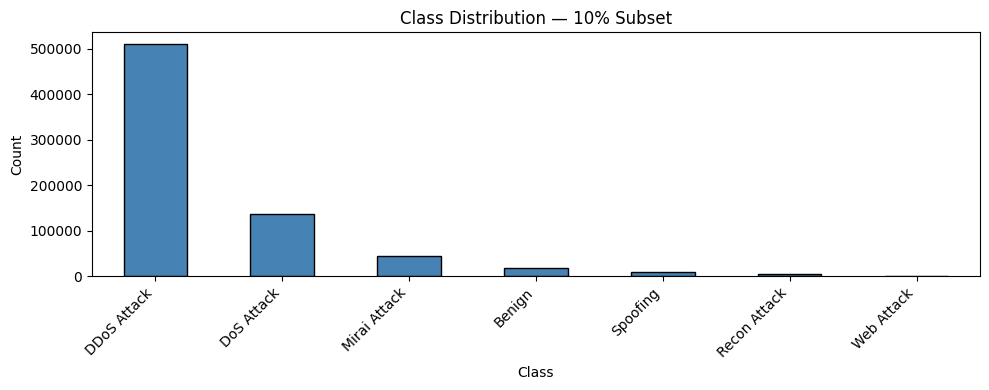

In [8]:
df, _ = train_test_split(
    df_raw, test_size=0.90,
    stratify=df_raw['attack_class'],
    random_state=SEED)

print(f'10% subset shape: {df.shape}')
print()
print('Class distribution in subset:')
print(df['attack_class'].value_counts().to_string())

# Plot
plt.figure(figsize=(10, 4))
df['attack_class'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Class Distribution — 10% Subset')
plt.xlabel('Class'); plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

## Step 8 — Preprocess Features

In [9]:
# Columns to drop (non-feature columns)
drop_cols = ['attack_class', label_col,
             'Timestamp', 'timestamp', 'Flow ID', 'flow_id',
             'Src IP', 'src_ip', 'Dst IP', 'dst_ip',
             'Src Port', 'Dst Port']
drop_cols = [c for c in drop_cols if c in df.columns]

y_raw = df['attack_class'].values
X_df  = df.drop(columns=drop_cols).select_dtypes(include=[np.number])

# Handle inf and NaN
X_df = X_df.replace([np.inf, -np.inf], np.nan)
X_df = X_df.fillna(X_df.median())

X = X_df.values.astype(np.float32)

# Encode string labels to integers
le          = LabelEncoder()
y           = le.fit_transform(y_raw)
class_names = le.classes_.tolist()

print(f'Feature count : {X.shape[1]}')
print(f'Sample count  : {X.shape[0]}')
print(f'Classes ({len(class_names)}): {class_names}')

Feature count : 46
Sample count  : 723920
Classes (7): ['Benign', 'DDoS Attack', 'DoS Attack', 'Mirai Attack', 'Recon Attack', 'Spoofing', 'Web Attack']


## Step 9 — 70/30 Split → Standardize → SMOTE
All three steps follow the base paper exactly. Scaler is fit on train only.

In [10]:
# 70 / 30 split
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)

print(f'Train: {X_train_raw.shape}  |  Test: {X_test.shape}')

# Standardize (fit on train, apply to both)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw).astype(np.float32)
X_test_sc  = scaler.transform(X_test).astype(np.float32)
print('Standardization done.')

# SMOTE
min_count = min(Counter(y_train_raw).values())
k_nn      = min(5, min_count - 1)
print(f'SMOTE k_neighbors = {k_nn}  (min class size = {min_count})')

smote = SMOTE(random_state=SEED, k_neighbors=k_nn)
X_train, y_train = smote.fit_resample(X_train_sc, y_train_raw)
X_train = X_train.astype(np.float32)

print(f'After SMOTE — Train: {X_train.shape}')
print('Class distribution after SMOTE:')
for cls, cnt in sorted(Counter(y_train).items()):
    print(f'  {class_names[cls]:<20}: {cnt:,}')

Train: (506744, 46)  |  Test: (217176, 46)
Standardization done.
SMOTE k_neighbors = 5  (min class size = 220)
After SMOTE — Train: (2503235, 46)
Class distribution after SMOTE:
  Benign              : 357,605
  DDoS Attack         : 357,605
  DoS Attack          : 357,605
  Mirai Attack        : 357,605
  Recon Attack        : 357,605
  Spoofing            : 357,605
  Web Attack          : 357,605


## Step 10 — Define Autoencoder
Equations (8) and (9) from the paper: LeakyReLU + BatchNorm, bottleneck = input_dim // 2.

In [11]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        h = input_dim // 2
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, h),
            nn.BatchNorm1d(h),
            nn.LeakyReLU(0.2))
        self.decoder = nn.Sequential(
            nn.Linear(h, input_dim),
            nn.BatchNorm1d(input_dim),
            nn.LeakyReLU(0.2))

    def forward(self, x):
        enc = self.encoder(x)
        dec = self.decoder(enc)
        return enc, dec

print('Autoencoder defined.')

Autoencoder defined.


## Step 11 — Define LSTM Encoder
Equations (10)–(15): 2-layer LSTM, returns last hidden state.

In [12]:
class LSTMEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.2)

    def forward(self, x):
        # x: (B, D) -> unsqueeze -> (B, 1, D) single time-step
        _, (hn, _) = self.lstm(x.unsqueeze(1))
        return hn[-1]   # (B, hidden_dim)

print('LSTMEncoder defined.')

LSTMEncoder defined.


## Step 12 — Define 1D CNN Classifier
Applied on the merged [AE ; LSTM] feature vector.

In [13]:
class CNNClassifier(nn.Module):
    def __init__(self, merged_dim, num_classes):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 64,  kernel_size=3, padding=1),
            nn.BatchNorm1d(64),  nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2))

        flat_size = (merged_dim // 4) * 128
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes))

    def forward(self, x):
        # x: (B, merged_dim) -> (B, 1, merged_dim)
        return self.fc(self.cnn(x.unsqueeze(1)))

print('CNNClassifier defined.')

CNNClassifier defined.


## Step 13 — Full Model: AE + LSTM + CNN

In [14]:
class AE_LSTM_CNN(nn.Module):
    """
    Base paper full pipeline:
      Parallel(AE, LSTM)  ->  Concat  ->  CNN  ->  Softmax
    """
    def __init__(self, input_dim, num_classes, lstm_hidden=128):
        super().__init__()
        self.ae   = Autoencoder(input_dim)
        self.lstm = LSTMEncoder(input_dim, lstm_hidden)
        merged    = (input_dim // 2) + lstm_hidden
        self.cnn  = CNNClassifier(merged, num_classes)

    def forward(self, x):
        ae_enc, ae_dec = self.ae(x)
        lstm_out       = self.lstm(x)
        merged         = torch.cat([ae_enc, lstm_out], dim=1)
        logits         = self.cnn(merged)
        return logits, ae_dec

# ── Instantiate ──
INPUT_DIM   = X_train.shape[1]
NUM_CLASSES = len(class_names)

model = AE_LSTM_CNN(INPUT_DIM, NUM_CLASSES).to(device)

total_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Input dim    : {INPUT_DIM}')
print(f'Num classes  : {NUM_CLASSES}')
print(f'Classes      : {class_names}')
print(f'Parameters   : {total_p:,}')

Input dim    : 46
Num classes  : 7
Classes      : ['Benign', 'DDoS Attack', 'DoS Attack', 'Mirai Attack', 'Recon Attack', 'Spoofing', 'Web Attack']
Parameters   : 1,464,346


## Step 14 — DataLoaders

In [15]:
BATCH = 512

train_ds = TensorDataset(
    torch.tensor(X_train),
    torch.tensor(y_train, dtype=torch.long))
test_ds = TensorDataset(
    torch.tensor(X_test_sc),
    torch.tensor(y_test,  dtype=torch.long))

train_loader = DataLoader(train_ds, batch_size=BATCH,
                          shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader):,}')
print(f'Test  batches : {len(test_loader):,}')

Train batches : 4,890
Test  batches : 425


In [25]:
!pip install verbose

ERROR: Could not find a version that satisfies the requirement verbose (from versions: none)
ERROR: No matching distribution found for verbose


## Step 15 — Loss, Optimizer, Scheduler

In [16]:
ce_loss  = nn.CrossEntropyLoss()
mse_loss = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5)

EPOCHS    = 100
AE_LOSS_W = 0.1

print('Setup complete. Ready to train.')

Setup complete. Ready to train.


## Step 16 — Train & Evaluate Functions

In [17]:
def train_epoch(model, loader, opt):
    model.train()
    total_loss = correct = total = 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        opt.zero_grad()
        logits, ae_dec = model(Xb)
        loss = ce_loss(logits, yb) + AE_LOSS_W * mse_loss(ae_dec, Xb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        total_loss += loss.item() * Xb.size(0)
        correct    += (logits.argmax(1) == yb).sum().item()
        total      += Xb.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, labels = [], []
    for Xb, yb in loader:
        logits, _ = model(Xb.to(device))
        preds.extend(logits.argmax(1).cpu().numpy())
        labels.extend(yb.numpy())
    return np.array(labels), np.array(preds)


print('Functions defined.')

Functions defined.


## Step 17 — Train for 100 Epochs

In [18]:
import os, json
import numpy as np
from sklearn.metrics import accuracy_score
import torch

tr_losses, tr_accs, vl_accs = [], [], []
best_acc, best_state = 0.0, None

print(f'Training on {device} ...')
print(f'{"Ep":>5} | {"TrLoss":>9} | {"TrAcc":>7} | {"ValAcc":>7}')
print('-' * 38)

for ep in range(1, EPOCHS + 1):
    tr_loss, tr_acc     = train_epoch(model, train_loader, optimizer)
    vl_labels, vl_preds = evaluate(model, test_loader)
    vl_acc              = accuracy_score(vl_labels, vl_preds)

    scheduler.step(tr_loss)
    tr_losses.append(tr_loss)
    tr_accs.append(tr_acc)
    vl_accs.append(vl_acc)

    if vl_acc > best_acc:
        best_acc   = vl_acc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    # Save checkpoint every 10 epochs
    if ep % 10 == 0:
        torch.save({
            'epoch':       ep,
            'model_state': best_state,
            'tr_losses':   tr_losses,
            'tr_accs':     tr_accs,
            'vl_accs':     vl_accs,
            'best_acc':    best_acc,
            'class_names': class_names,
            'input_dim':   INPUT_DIM,
            'num_classes': NUM_CLASSES,
        }, f'/kaggle/working/checkpoint_ep{ep}.pth')
        print(f'  >>> Checkpoint saved at epoch {ep}')

    if ep % 10 == 0 or ep == 1:
        print(f'{ep:>5} | {tr_loss:>9.5f} | {tr_acc*100:>6.2f}% | {vl_acc*100:>6.2f}%')

print(f'\nBest Validation Accuracy: {best_acc*100:.2f}%')

# ── Save final model immediately after training ──
torch.save({
    'model_state': best_state,
    'tr_losses':   tr_losses,
    'tr_accs':     tr_accs,
    'vl_accs':     vl_accs,
    'best_acc':    best_acc,
    'class_names': class_names,
    'input_dim':   INPUT_DIM,
    'num_classes': NUM_CLASSES,
}, '/kaggle/working/base_paper_model_FINAL.pth')
print('Model saved to /kaggle/working/base_paper_model_FINAL.pth')

Training on cuda ...
   Ep |    TrLoss |   TrAcc |  ValAcc
--------------------------------------
    1 |   0.51402 |  84.08% |  79.48%
  >>> Checkpoint saved at epoch 10
   10 |   0.20306 |  92.60% |  81.44%
  >>> Checkpoint saved at epoch 20
   20 |   0.18459 |  93.39% |  75.96%
  >>> Checkpoint saved at epoch 30
   30 |   0.14182 |  96.40% |  80.52%
  >>> Checkpoint saved at epoch 40
   40 |   0.13047 |  96.87% |  83.38%
  >>> Checkpoint saved at epoch 50
   50 |   0.10472 |  98.11% |  86.52%
  >>> Checkpoint saved at epoch 60
   60 |   0.09960 |  98.28% |  76.44%
  >>> Checkpoint saved at epoch 70
   70 |   0.09624 |  98.43% |  97.01%
  >>> Checkpoint saved at epoch 80
   80 |   0.09376 |  98.50% |  97.19%
  >>> Checkpoint saved at epoch 90
   90 |   0.09190 |  98.59% |  91.28%
  >>> Checkpoint saved at epoch 100
  100 |   0.09063 |  98.62% |  94.79%

Best Validation Accuracy: 98.26%
Model saved to /kaggle/working/base_paper_model_FINAL.pth


## Step 18 — Training Curves

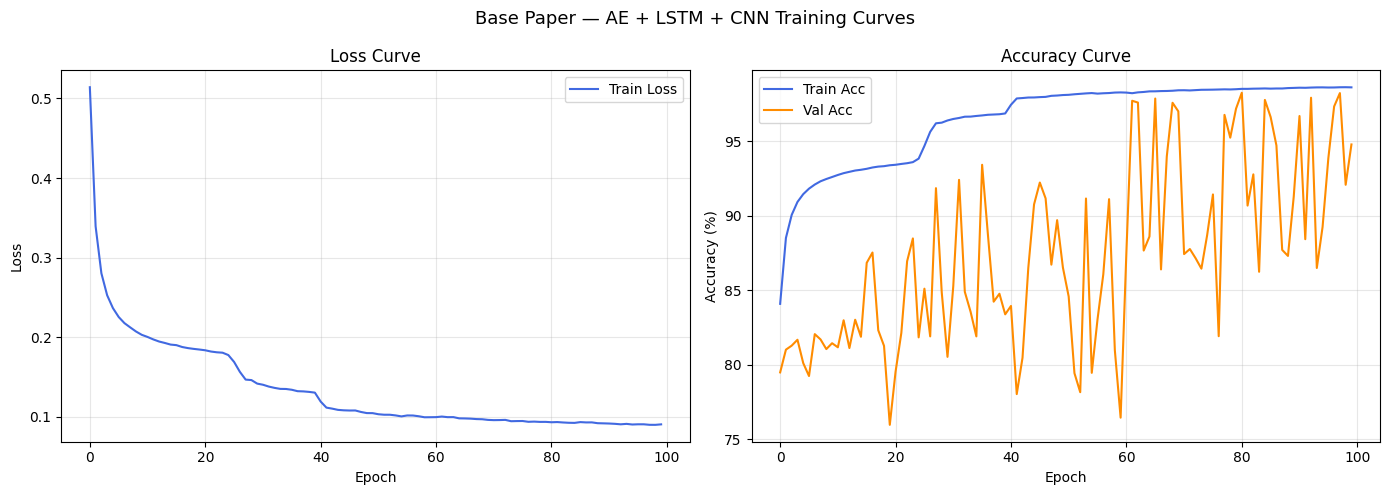

In [19]:
import matplotlib.pyplot as plt

# Safety check before plotting
for var_name, var in [('tr_losses', 'tr_losses'), ('tr_accs', 'tr_accs'), ('vl_accs', 'vl_accs')]:
    if var_name not in dir():
        print(f'ERROR: [{var_name}] not defined — please run the training cell first')
        raise SystemExit

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(tr_losses, color='royalblue', label='Train Loss')
axes[0].set(title='Loss Curve', xlabel='Epoch', ylabel='Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot([a*100 for a in tr_accs], color='royalblue',  label='Train Acc')
axes[1].plot([a*100 for a in vl_accs], color='darkorange', label='Val Acc')
axes[1].set(title='Accuracy Curve', xlabel='Epoch', ylabel='Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Base Paper — AE + LSTM + CNN Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig('base_training_curves.png', dpi=150)
plt.show()

## Step 19 — Final Evaluation (Best Model)

In [20]:
model.load_state_dict(best_state)
y_true, y_pred = evaluate(model, test_loader)

acc  = accuracy_score(y_true,  y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_true,    y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_true,        y_pred, average='weighted', zero_division=0)

print('=' * 55)
print('       BASE PAPER — OVERALL RESULTS')
print('=' * 55)
print(f'  Accuracy  : {acc*100:.2f}%   (paper target: 99.15%)')
print(f'  Precision : {prec*100:.2f}%   (paper target: 99.39%)')
print(f'  Recall    : {rec*100:.2f}%   (paper target: 99.00%)')
print(f'  F1 Score  : {f1*100:.2f}%   (paper target: 99.19%)')
print('=' * 55)

       BASE PAPER — OVERALL RESULTS
  Accuracy  : 98.26%   (paper target: 99.15%)
  Precision : 98.28%   (paper target: 99.39%)
  Recall    : 98.26%   (paper target: 99.00%)
  F1 Score  : 98.26%   (paper target: 99.19%)


## Step 20 — Per-Class Results vs Paper Table I

In [21]:
cm      = confusion_matrix(y_true, y_pred)
pc_acc  = cm.diagonal() / cm.sum(axis=1)
pc_prec = precision_score(y_true, y_pred, average=None, zero_division=0)
pc_rec  = recall_score(y_true,    y_pred, average=None, zero_division=0)
pc_f1   = f1_score(y_true,        y_pred, average=None, zero_division=0)

print('YOUR RESULTS:')
print(f'  {"Class":<20} {"Acc":>7} {"Prec":>7} {"Rec":>7} {"F1":>7}')
print('  ' + '-'*50)
for i, cls in enumerate(class_names):
    print(f'  {cls:<20} {pc_acc[i]*100:>6.2f}% {pc_prec[i]*100:>6.2f}% {pc_rec[i]*100:>6.2f}% {pc_f1[i]*100:>6.2f}%')
print('  ' + '-'*50)
print(f'  {"Overall":<20} {acc*100:>6.2f}% {prec*100:>6.2f}% {rec*100:>6.2f}% {f1*100:>6.2f}%')

paper = {
    'Benign':       (99.95, 99.96, 99.97, 99.97),
    'Brute Force':  (99.57, 75.58, 64.19, 69.42),
    'DDoS Attack':  (99.39, 82.91, 93.26, 87.78),
    'DoS Attack':   (99.97, 99.95, 99.91, 99.93),
    'Mirai Attack': (99.99, 99.98, 99.97, 99.98),
    'Recon Attack': (99.98, 98.48, 14.38, 25.10),
    'Spoofing':     (99.95, 61.64,  5.33,  9.81),
    'Web Attack':   (99.49, 78.58, 70.64, 74.40),
}
print()
print('PAPER REPORTED (Table I):')
print(f'  {"Class":<20} {"Acc":>7} {"Prec":>7} {"Rec":>7} {"F1":>7}')
print('  ' + '-'*50)
for cls, (a,p,r,f) in paper.items():
    print(f'  {cls:<20} {a:>6.2f}% {p:>6.2f}% {r:>6.2f}% {f:>6.2f}%')

YOUR RESULTS:
  Class                    Acc    Prec     Rec      F1
  --------------------------------------------------
  Benign                86.70%  85.58%  86.70%  86.14%
  DDoS Attack           98.99%  99.93%  98.99%  99.46%
  DoS Attack            99.71%  96.50%  99.71%  98.08%
  Mirai Attack          99.68%  99.43%  99.68%  99.55%
  Recon Attack          66.69%  67.56%  66.69%  67.12%
  Spoofing              73.50%  72.94%  73.50%  73.22%
  Web Attack            16.84%  19.05%  16.84%  17.88%
  --------------------------------------------------
  Overall               98.26%  98.28%  98.26%  98.26%

PAPER REPORTED (Table I):
  Class                    Acc    Prec     Rec      F1
  --------------------------------------------------
  Benign                99.95%  99.96%  99.97%  99.97%
  Brute Force           99.57%  75.58%  64.19%  69.42%
  DDoS Attack           99.39%  82.91%  93.26%  87.78%
  DoS Attack            99.97%  99.95%  99.91%  99.93%
  Mirai Attack          99.99%

## Step 21 — Confusion Matrix

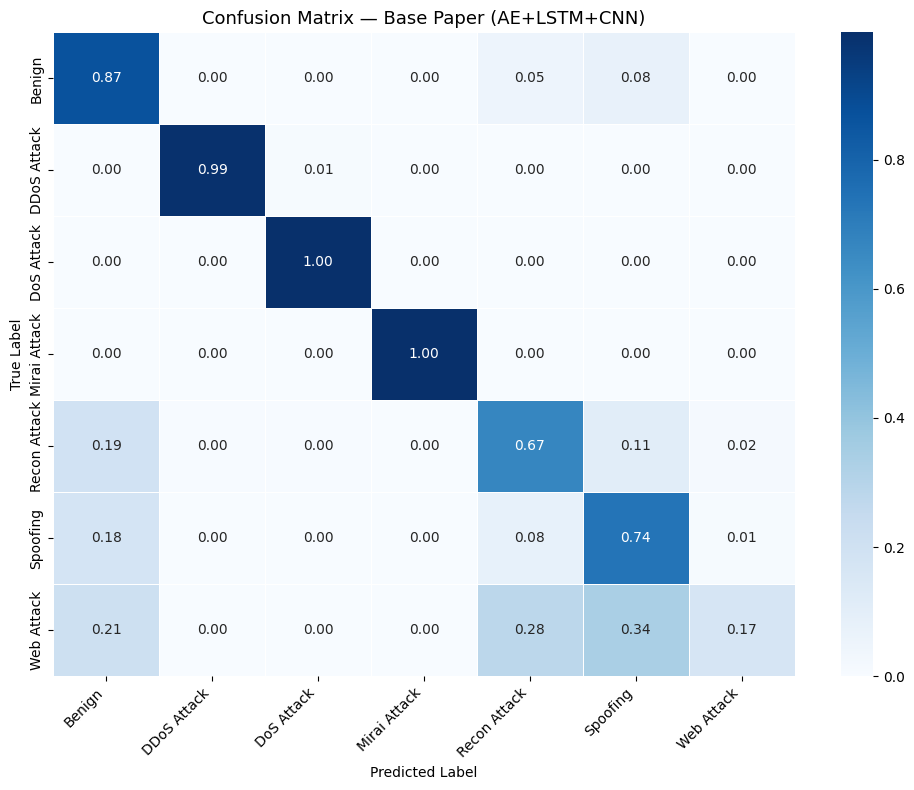

In [22]:
plt.figure(figsize=(10, 8))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5)
plt.title('Confusion Matrix — Base Paper (AE+LSTM+CNN)', fontsize=13)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig('base_confusion_matrix.png', dpi=150)
plt.show()

## Step 22 — Per-Class F1 Bar Chart

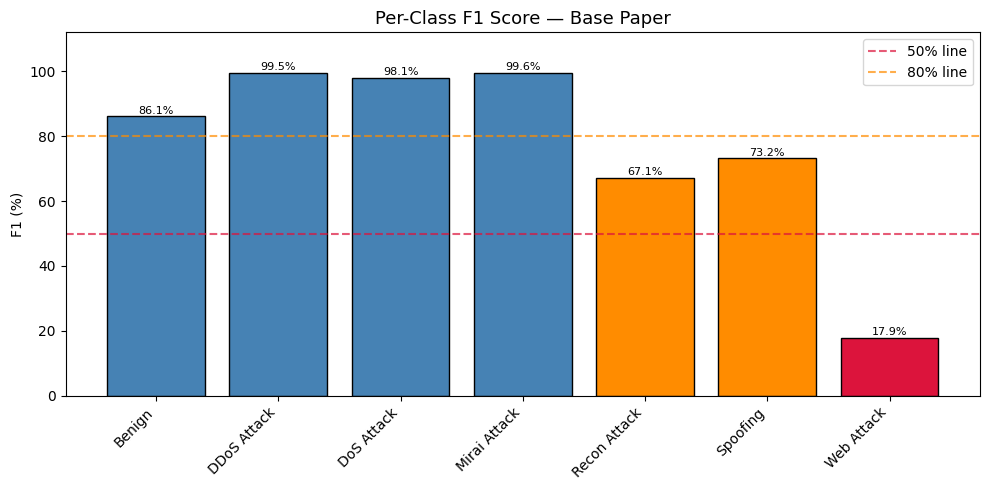

Note: Spoofing and Recon low F1 is the core problem we fix in the improved model.


In [23]:
colors = ['crimson' if f < 0.5 else 'darkorange' if f < 0.8 else 'steelblue'
          for f in pc_f1]
plt.figure(figsize=(10, 5))
bars = plt.bar(class_names, pc_f1 * 100, color=colors, edgecolor='black')
plt.axhline(50, color='crimson',    linestyle='--', alpha=0.7, label='50% line')
plt.axhline(80, color='darkorange', linestyle='--', alpha=0.7, label='80% line')
for bar, val in zip(bars, pc_f1 * 100):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f'{val:.1f}%', ha='center', fontsize=8)
plt.title('Per-Class F1 Score — Base Paper', fontsize=13)
plt.ylabel('F1 (%)'); plt.ylim(0, 112)
plt.xticks(rotation=45, ha='right'); plt.legend(); plt.tight_layout()
plt.savefig('base_f1_perclass.png', dpi=150)
plt.show()
print('Note: Spoofing and Recon low F1 is the core problem we fix in the improved model.')

## Step 23 — Save Results & Model Checkpoint

In [24]:
results = {
    'overall': {
        'accuracy':  float(acc),
        'precision': float(prec),
        'recall':    float(rec),
        'f1':        float(f1)
    },
    'per_class': {
        class_names[i]: {
            'accuracy':  float(pc_acc[i]),
            'precision': float(pc_prec[i]),
            'recall':    float(pc_rec[i]),
            'f1':        float(pc_f1[i])
        }
        for i in range(len(class_names))
    }
}

with open('base_paper_results.json', 'w') as fp:
    json.dump(results, fp, indent=2)

torch.save({
    'model_state_dict': best_state,
    'input_dim':   INPUT_DIM,
    'num_classes': NUM_CLASSES,
    'class_names': class_names
}, 'base_paper_model.pth')

print('Saved -> base_paper_results.json')
print('Saved -> base_paper_model.pth')
print()
print('Base paper implementation COMPLETE.')
print('Next step: QA-CVAE + AE-LSTM-Attention (improved model).')

Saved -> base_paper_results.json
Saved -> base_paper_model.pth

Base paper implementation COMPLETE.
Next step: QA-CVAE + AE-LSTM-Attention (improved model).
